# Populate Qdrant

This notebook feeds all ZMS code as content into the qdrant container running on localhost:6333. In combination with a second container running ollama the setup works as RAG (Retrieval Augmented Generation) and can answer questions about ZMS, even invent new API functions and features, too. So, stay critical and don't stop thinking for yourself!

![llm_qdrant.gif](../images/llm_qdrant.gif)

**Prerequisites**: 
The Python environment needs the following packages to be installed
1. qdrant_client
2. sentence_transformers
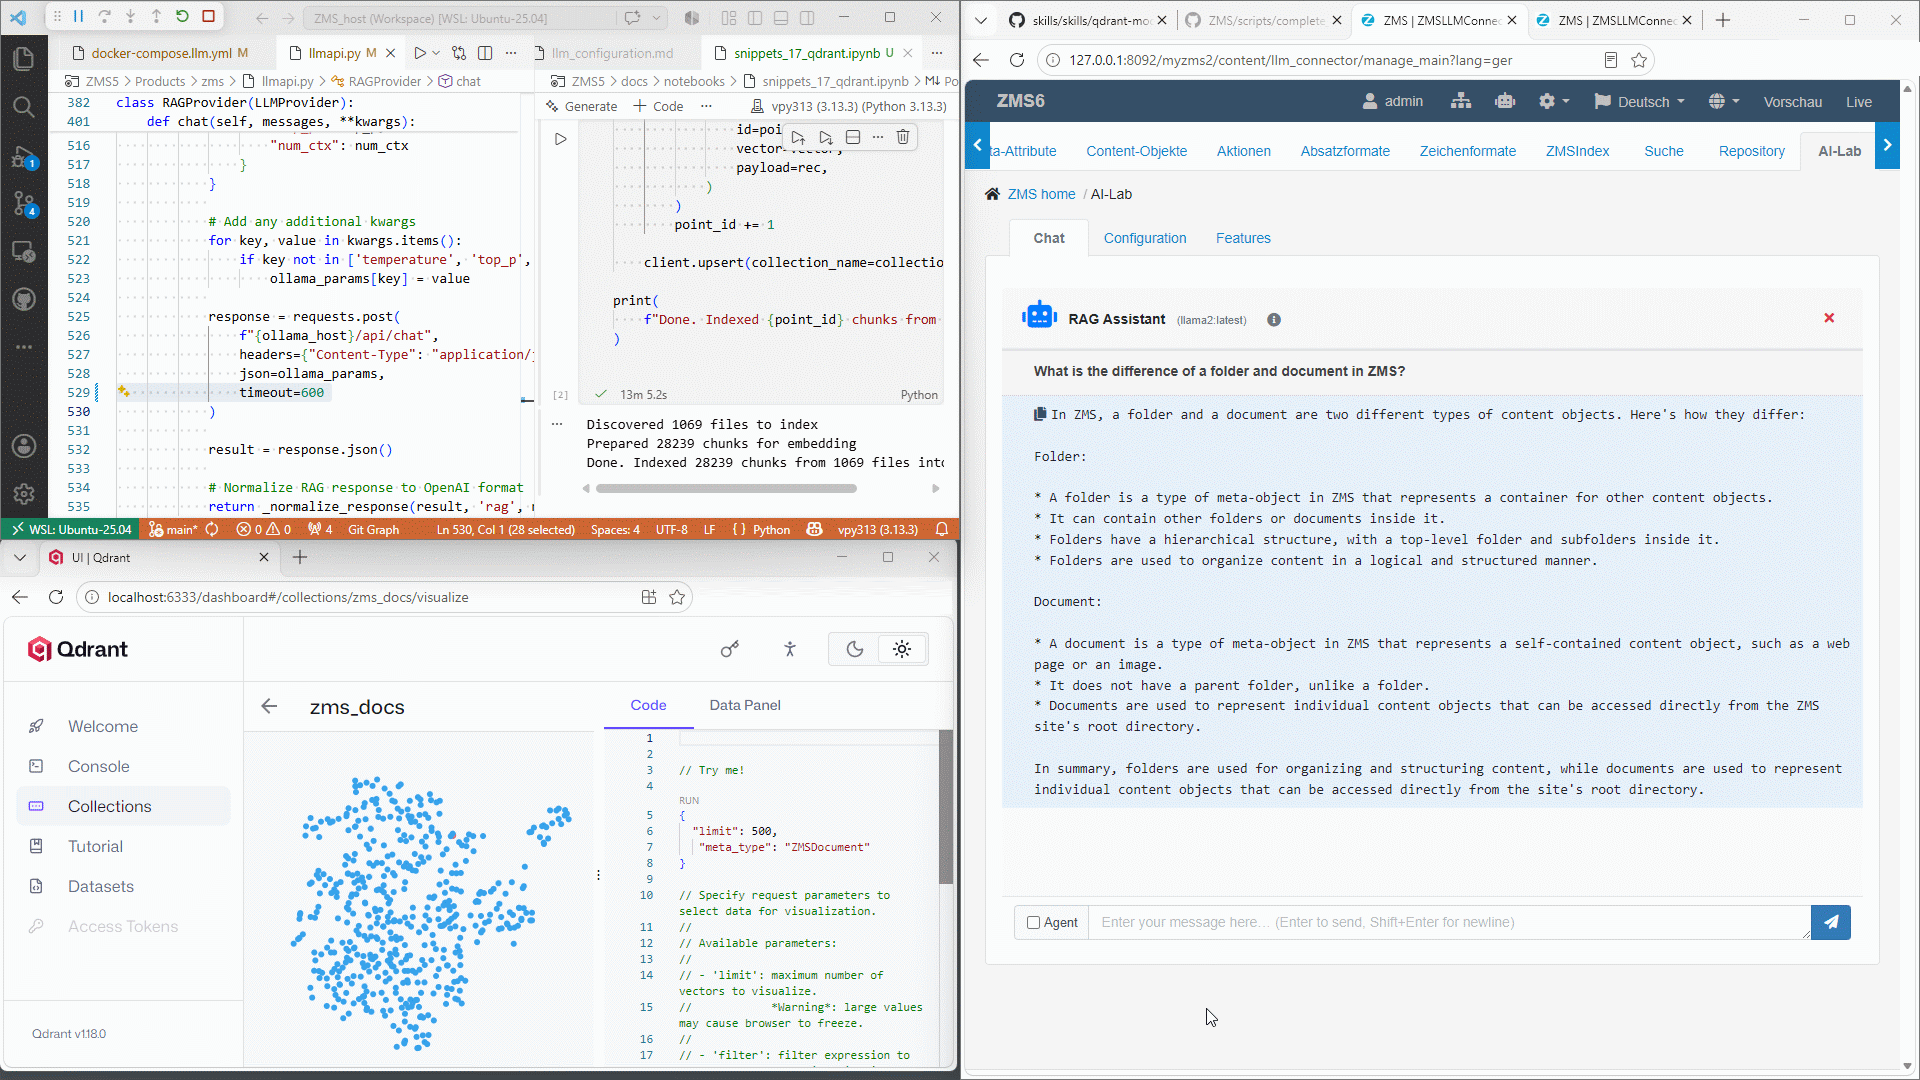

In [3]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
# Initialize embedding model (use the same as llm.embedding.model)
model = SentenceTransformer('all-MiniLM-L6-v2')

# Connect to Qdrant
client = QdrantClient(host="localhost", port=6333)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3198.80it/s]


In [7]:
from pathlib import Path

# Repository root (this notebook is in docs/notebooks/)
repo_root = Path.cwd().resolve().parents[1]
collection_name = "zms_docs"

# Include code and documentation files
include_suffixes = {
    ".py", ".zpt", ".dtml", ".ipynb",
    ".js", ".html", ".xml", ".zcml",
    ".json", ".yml", ".yaml", ".ini", ".cfg", ".toml",
    ".md", ".rst", ".txt", ".sh"
}

# Skip large/generated/vendor folders
exclude_dirs = {
    ".git", "node_modules", "__pycache__", ".pytest_cache",
    "venv", ".venv", "dist", "build", "ZMS.egg-info", "test_output",
    "data", "pgdata", "var"
}


def should_index_file(path: Path) -> bool:
    if path.suffix.lower() not in include_suffixes:
        return False
    for part in path.parts:
        if part in exclude_dirs:
            return False
    return path.is_file()


def read_text_file(path: Path) -> str | None:
    try:
        return path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        try:
            return path.read_text(encoding="latin-1")
        except Exception:
            return None
    except Exception:
        return None


def chunk_text(text: str, chunk_size: int = 1200, overlap: int = 200) -> list[str]:
    text = text.strip()
    if not text:
        return []
    chunks = []
    start = 0
    step = max(chunk_size - overlap, 1)
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
        start += step
    return chunks


# Recreate collection to keep notebook reruns predictable
try:
    client.delete_collection(collection_name=collection_name)
except Exception as e:
    print(f"Collection deletion skipped: {e}")

client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=384, distance=Distance.COSINE),
)

# Discover files
candidate_files = [p for p in repo_root.rglob("*") if should_index_file(p)]

print(f"Discovered {len(candidate_files)} files to index")


# Build chunks and payloads
records = []
for file_path in candidate_files:
    content = read_text_file(file_path)
    if not content:
        continue

    rel_path = file_path.relative_to(repo_root).as_posix()
    chunks = chunk_text(content)

    for i, chunk in enumerate(chunks):
        records.append(
            {
                "text": chunk,
                "path": rel_path,
                "filename": file_path.name,
                "file_type": file_path.suffix.lower(),
                "chunk_index": i,
            }
        )

print(f"Prepared {len(records)} chunks for embedding")


# -------------------------------------
# DRY RUN - Set to False to actually index
# -------------------------------------
dry_run = False
# -------------------------------------
if dry_run:
    print("Dry run enabled - no data will be indexed. Set dry_run = False to proceed.")
else:
    # Embed and upsert in batches
    batch_size = 64
    point_id = 0
    for i in range(0, len(records), batch_size):
        batch = records[i:i + batch_size]
        vectors = model.encode([r["text"] for r in batch]).tolist()

        points = []
        for rec, vector in zip(batch, vectors):
            points.append(
                PointStruct(
                    id=point_id,
                    vector=vector,
                    payload=rec,
                )
            )
            point_id += 1

        client.upsert(collection_name=collection_name, points=points)

    print(
        f"Done. Indexed {point_id} chunks from {len(candidate_files)} files into '{collection_name}'."
    )


Discovered 1201 files to index
Prepared 28837 chunks for embedding
Done. Indexed 28837 chunks from 1201 files into 'zms_docs'.
